# Game Patch Notes Analysis Notebook

This notebook loads `games_metadata_totals.csv` and provides code blocks to investigate:

- Number of patch notes per category (boxplot)
- Number of patch notes per genre (boxplot)
- Number of patch notes per generation (console generation)
- Number of patch notes for free vs non-free games
- Patch notes vs price
- Patch notes per platform (multiplatform)
- Patch notes per developer/publisher
- Patch notes per year (distribution)

Run each cell after updating any column names if needed.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", message="Glyph.*missing from font")
df = pd.read_csv('games_metadata_totals.csv')

C:\Users\Saksham\AppData\Local\Temp\ipykernel_47412\1831668400.py:6: DtypeWarning: Columns (3,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('games_metadata_totals.csv')


Patch notes per year (distribution)

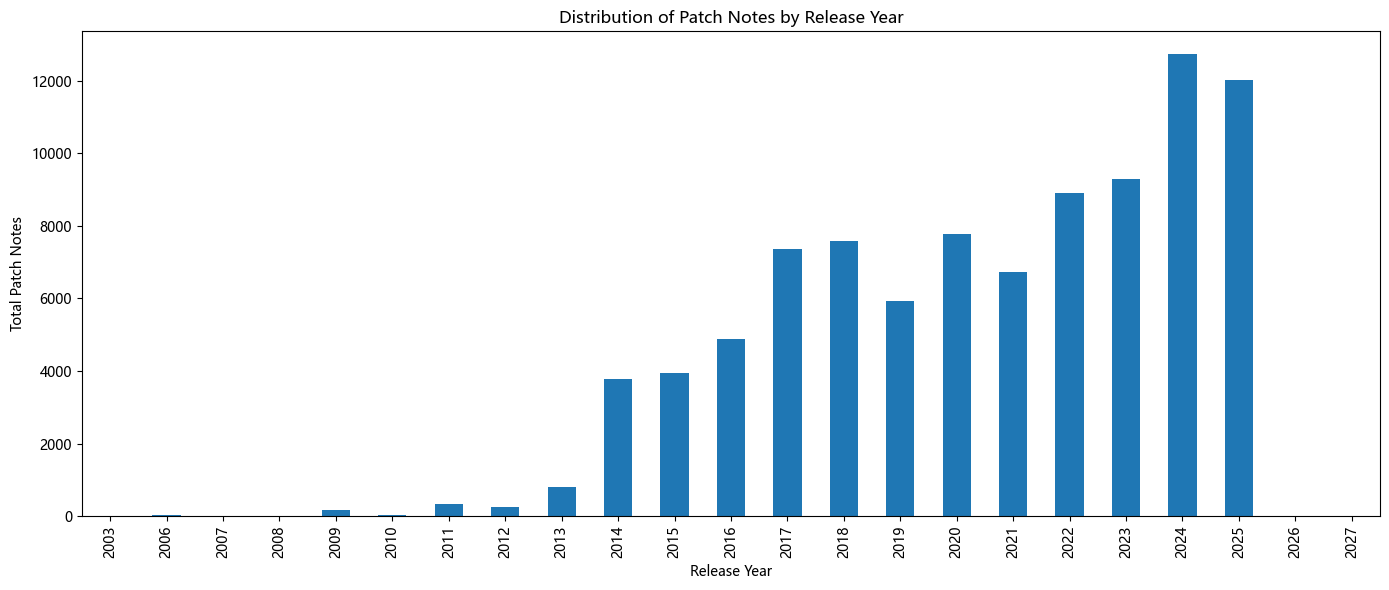

In [12]:
# Convert release date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df = df.dropna(subset=['release_date'])
df['release_year'] = df['release_date'].dt.year
df['release_year'] = df['release_year'].astype('Int64')
df['total_patches'] = df['total_patches'].fillna(0).astype(int)

patches_per_year = df.groupby('release_year')['total_patches'].sum()

# Plot
plt.figure(figsize=(14,6))
patches_per_year.plot(kind='bar')
plt.xlabel("Release Year")
plt.ylabel("Total Patch Notes")
plt.title("Distribution of Patch Notes by Release Year")
plt.tight_layout()
plt.show()

Number of patch notes per developer

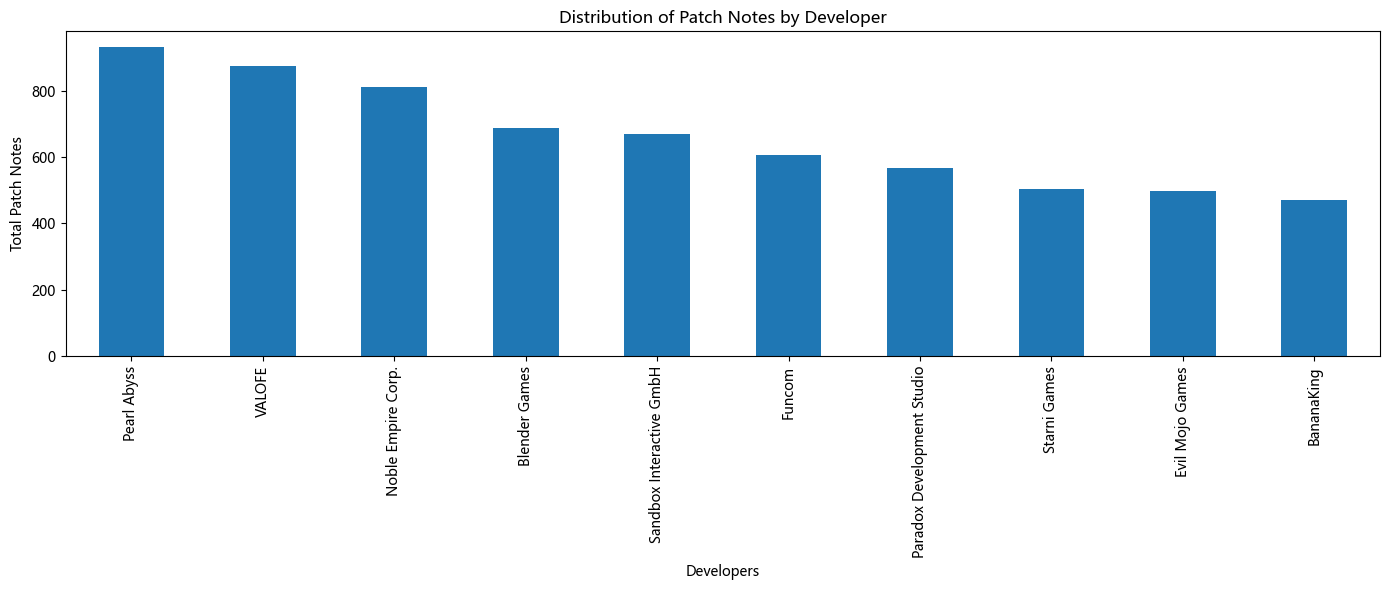

In [15]:
import pandas as pd

# Some rows have multiple developers separated by semicolons — split them
df['developers'] = df['developers'].fillna('').astype(str)

df_devs = df.assign(
    developer_list=df['developers'].str.split(';')
).explode('developer_list')

# Clean whitespace and remove empty entries
df_devs['developer_list'] = df_devs['developer_list'].str.strip()
df_devs = df_devs[df_devs['developer_list'] != '']

# Sum patches per developer
patches_per_developer = (
    df_devs.groupby('developer_list')['total_patches']
    .sum()
    .sort_values(ascending=False)
)

# print(patches_per_developer.head(50))

top10_developers = patches_per_developer.head(10)

# Plot
plt.figure(figsize=(14,6))
top10_developers.plot(kind='bar')
plt.xlabel("Developers")
plt.ylabel("Total Patch Notes")
plt.title("Distribution of Patch Notes by Developer")
plt.tight_layout()
plt.show()


  Number of patch notes per platform

{'Windows': np.int64(92512), 'Mac': np.int64(25370), 'Linux': np.int64(20614)}


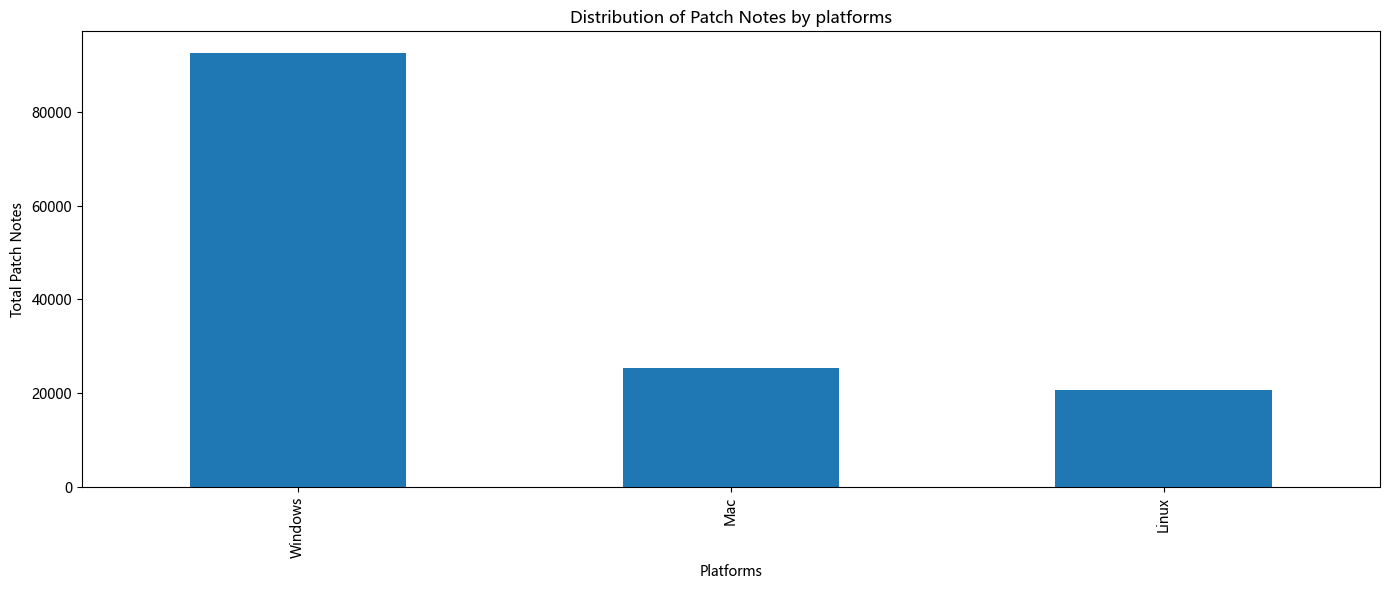

In [ ]:
for col in ['windows', 'mac', 'linux']:
    df[col] = df[col].astype(bool)

patches_per_platform = {
    'Windows': df.loc[df['windows'] == True, 'total_patches'].sum(),
    'Mac': df.loc[df['mac'] == True, 'total_patches'].sum(),
    'Linux': df.loc[df['linux'] == True, 'total_patches'].sum()
}

# Plot
plt.figure(figsize=(14,6))
pd.Series(patches_per_platform).plot(kind='bar')
plt.xlabel("Platforms")
plt.ylabel("Total Patch Notes")
plt.title("Distribution of Patch Notes by platforms")
plt.tight_layout()
plt.show()

 Number of patch notes on multiplatform

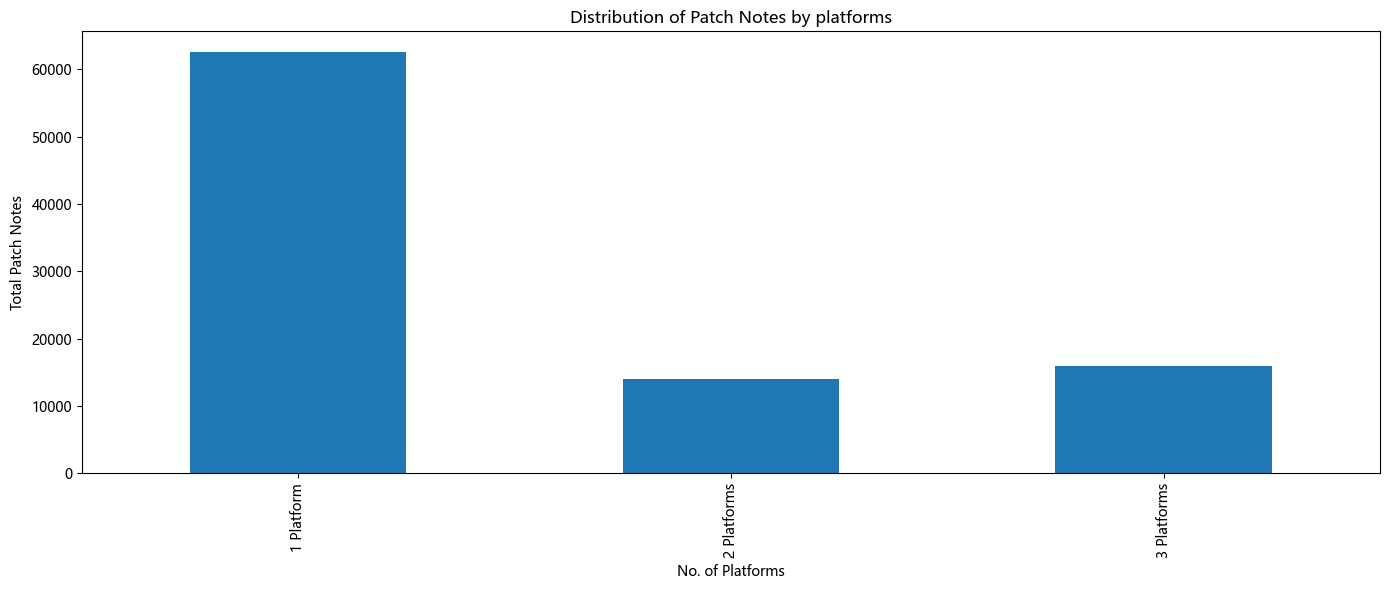

In [21]:
# Count how many platforms each game supports
df['platform_count'] = df[['windows', 'mac', 'linux']].sum(axis=1)

# 1-platform only
single_platform_patches = df.loc[df['platform_count'] == 1, 'total_patches'].sum()

# 2-platform games
two_platform_patches = df.loc[df['platform_count'] == 2, 'total_patches'].sum()

# All 3 platforms
three_platform_patches = df.loc[df['platform_count'] == 3, 'total_patches'].sum()

multiplatform_summary = {
    "1 Platform": single_platform_patches,
    "2 Platforms": two_platform_patches,
    "3 Platforms": three_platform_patches
}

# Plot
plt.figure(figsize=(14,6))
pd.Series(multiplatform_summary).plot(kind='bar')
plt.xlabel("No. of Platforms")
plt.ylabel("Total Patch Notes")
plt.title("Distribution of Patch Notes by platforms")
plt.tight_layout()
plt.show()

  Number of patch notes per price


C:\Users\Saksham\AppData\Local\Temp\ipykernel_47412\2878283008.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_range')['total_patches']


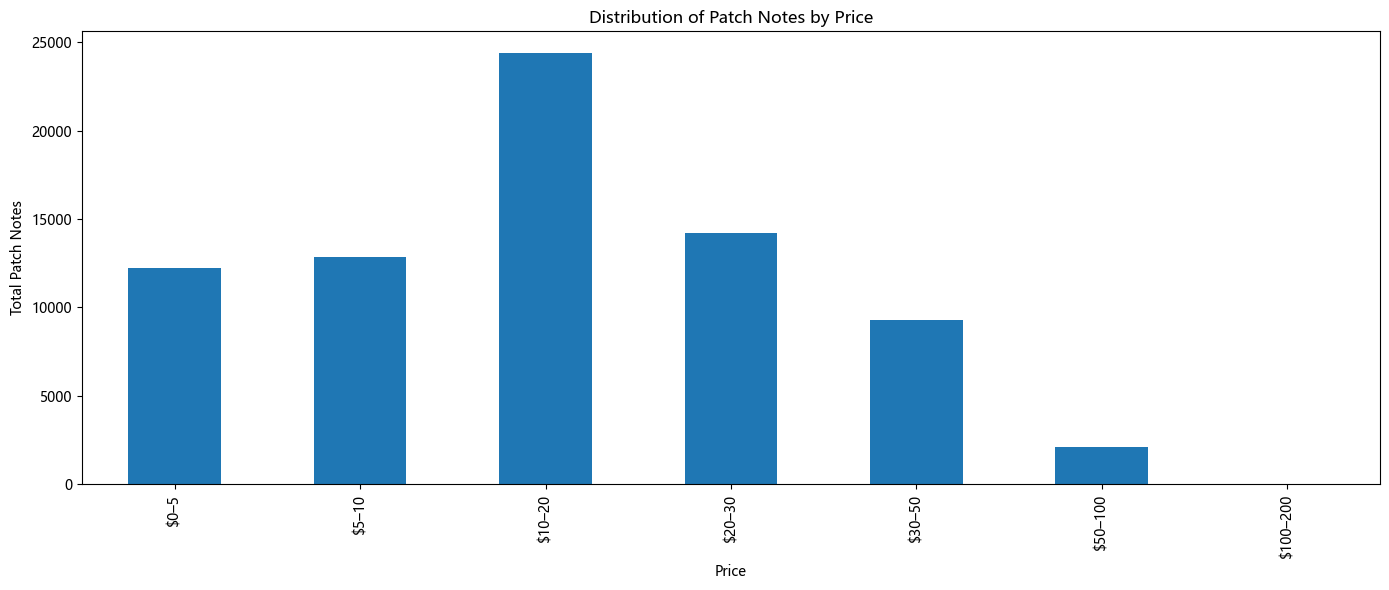

In [23]:
# Ensure price is numeric
df['price_final'] = pd.to_numeric(df['price_final'], errors='coerce')

# Drop rows without a price
df_price = df.dropna(subset=['price_final'])

bins = [0, 5, 10, 20, 30, 50, 100, 200]
labels = ["$0–5", "$5–10", "$10–20", "$20–30", "$30–50", "$50–100", "$100–200"]

df['price_range'] = pd.cut(df['price_final'], bins=bins, labels=labels, include_lowest=True)

# Group: total patch notes for each price point
patches_per_price = (
    df.groupby('price_range')['total_patches']
    .sum()
    .sort_index()
)

# Plot
plt.figure(figsize=(14,6))
patches_per_price.plot(kind='bar')
plt.xlabel("Price")
plt.ylabel("Total Patch Notes")
plt.title("Distribution of Patch Notes by Price")
plt.tight_layout()
plt.show()

Number of patch notes per free/non-free games


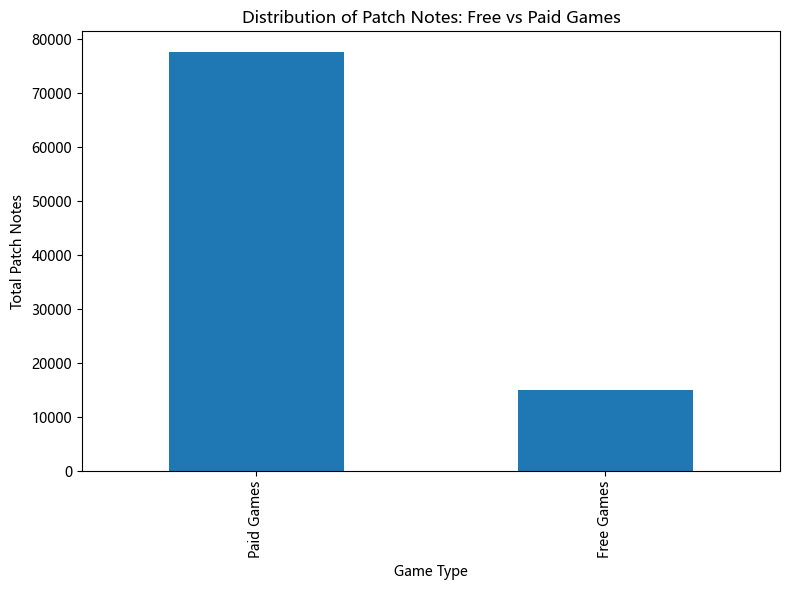

In [24]:
# Make sure is_free is boolean
df['is_free'] = df['is_free'].astype(bool)

# Group by free / non-free
patches_free_vs_paid = (
    df.groupby('is_free')['total_patches']
      .sum()
      .rename({True: "Free Games", False: "Paid Games"})
)

# Plot
plt.figure(figsize=(8,6))
patches_free_vs_paid.plot(kind='bar')
plt.xlabel("Game Type")
plt.ylabel("Total Patch Notes")
plt.title("Distribution of Patch Notes: Free vs Paid Games")
plt.tight_layout()
plt.show()

  Number of patch notes per genre (boxplot)


C:\Users\Saksham\AppData\Local\Temp\ipykernel_47412\1229766253.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(genre_patch_data, labels=genre_labels, vert=True)


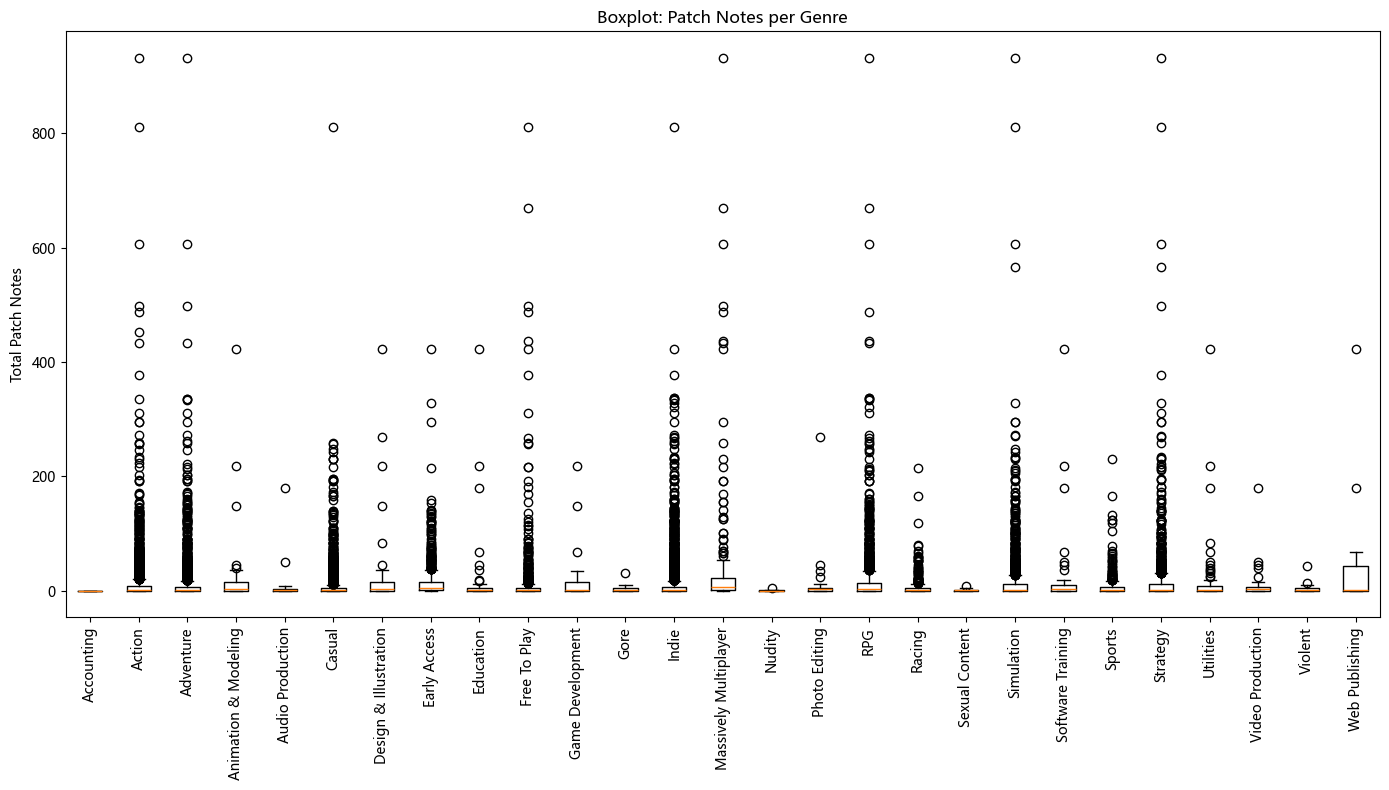

In [26]:
# Clean genres column
df['genres'] = df['genres'].fillna('').astype(str)

# Split genres into lists
df_genres = df.assign(
    genre=df['genres'].str.split(';')
).explode('genre')

# Remove empty genre entries
df_genres['genre'] = df_genres['genre'].str.strip()
df_genres = df_genres[df_genres['genre'] != ""]

# Create a list of patch counts per genre
genre_patch_data = [
    df_genres.loc[df_genres['genre'] == g, 'total_patches'].values
    for g in sorted(df_genres['genre'].unique())
]

genre_labels = sorted(df_genres['genre'].unique())

# Plot boxplot
plt.figure(figsize=(14, 8))
plt.boxplot(genre_patch_data, labels=genre_labels, vert=True)
plt.xticks(rotation=90)
plt.ylabel("Total Patch Notes")
plt.title("Boxplot: Patch Notes per Genre")
plt.tight_layout()
plt.show()


  - Number of patch notes per category (boxplot)

C:\Users\Saksham\AppData\Local\Temp\ipykernel_47412\3274591746.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(category_patch_data, labels=category_labels, vert=True)


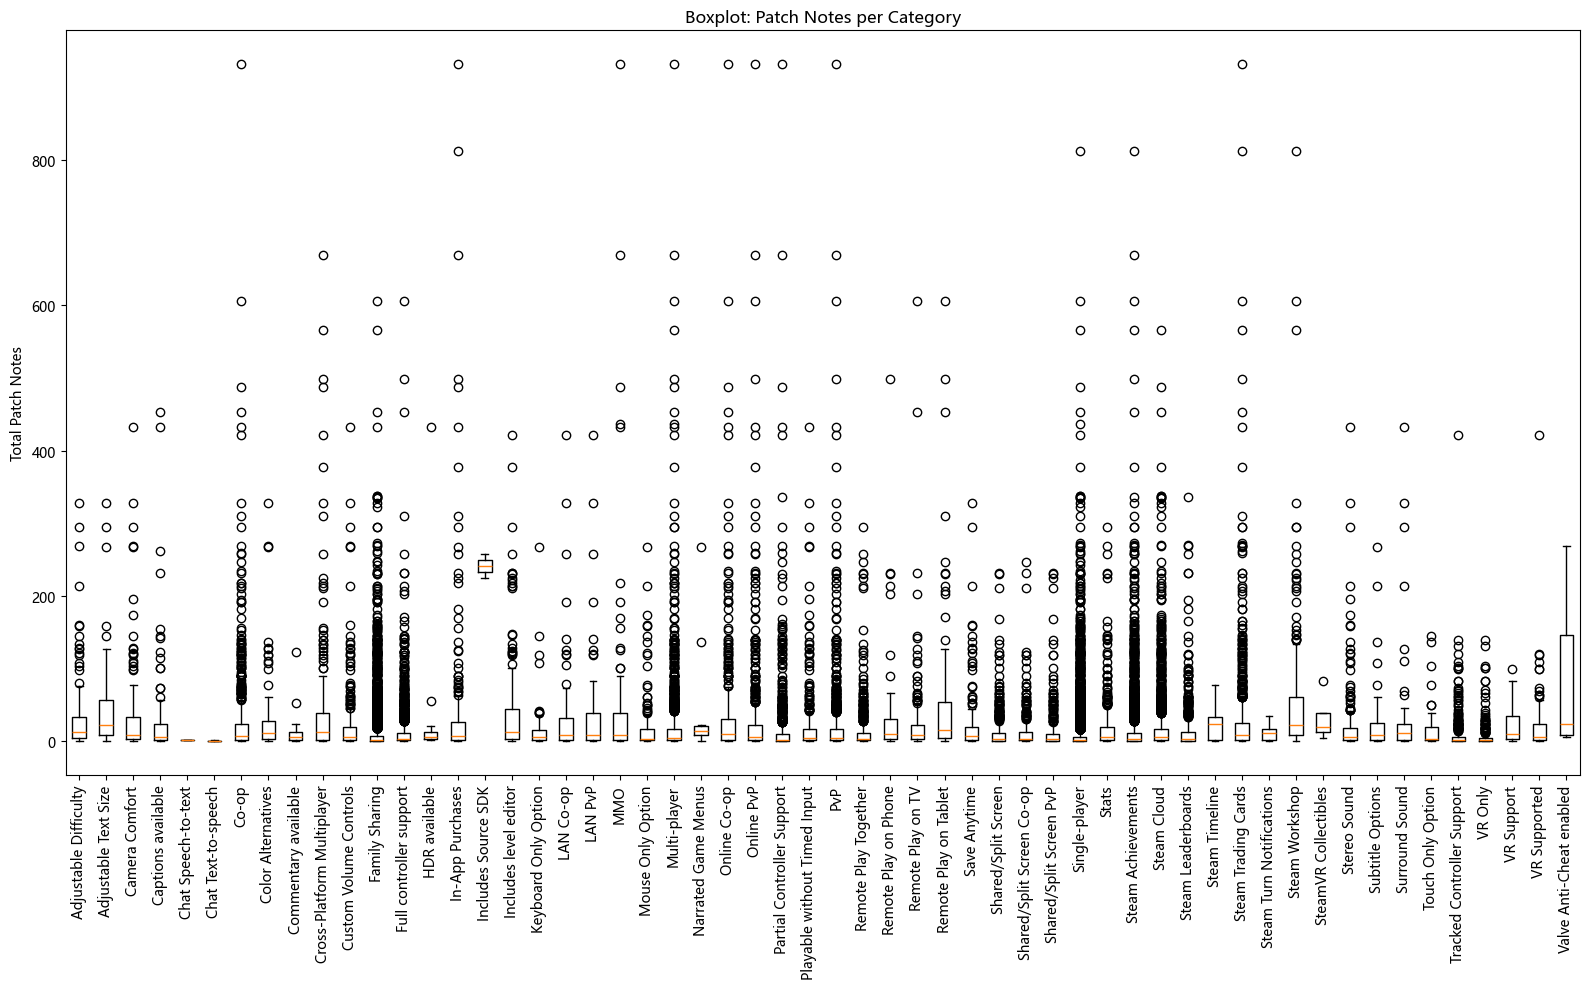

In [27]:
# Clean categories column
df['categories'] = df['categories'].fillna('').astype(str)

# Split categories into lists
df_cats = df.assign(
    category=df['categories'].str.split(';')
).explode('category')

# Clean whitespace + remove empty entries
df_cats['category'] = df_cats['category'].str.strip()
df_cats = df_cats[df_cats['category'] != ""]

# Make data for boxplot: list of arrays
category_patch_data = [
    df_cats.loc[df_cats['category'] == c, 'total_patches'].values
    for c in sorted(df_cats['category'].unique())
]

category_labels = sorted(df_cats['category'].unique())

# Plot boxplot
plt.figure(figsize=(16, 10))
plt.boxplot(category_patch_data, labels=category_labels, vert=True)
plt.xticks(rotation=90)
plt.ylabel("Total Patch Notes")
plt.title("Boxplot: Patch Notes per Category")
plt.tight_layout()
plt.show()
